In [19]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score
from tqdm import tqdm
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib import rcParams
import optuna
from Granger_causalFormer import PredictModel
from TCN_granger.data_create import simulate_var
from TCN_granger.granger_utils import (
    prox_group_lasso,
    prox_group_sparse_group_lasso,
    calculate_group_lasso_penalty,
    calculate_group_sparse_group_lasso_penalty
)

In [20]:
# 设置 Matplotlib 中文显示
rcParams['font.family'] = 'SimHei'
rcParams['axes.unicode_minus'] = False

# --- CSV 文件路径 ---
# 请将 "path/to/your/a.csv" 和 "path/to/your/b.csv" 替换为您的实际文件路径
FILE_A_PATH = "a.csv"  # 您的时序数据文件
FILE_B_PATH = "b.csv"  # 您的因果关系数据文件 (无表头)

# --- 参数设置 (部分参数将从数据中动态获取) ---
# P # 时间序列的数量 (将从 a.csv 中获取)
# T # 总时间点 (将从 a.csv 中获取)
# LAG # 真实的 VAR 滞后 (如果 b.csv 中有延迟信息，可以考虑使用，但当前代码主要关注因果关系的有无)
DATA_SEED = 42  # 用于可重复性的随机种子 (主要用于数据分割)
FEATURE_DIM = 1 # 假设每个列是一个单变量时间序列
OUTPUT_DIM = 1  # 假设预测序列值本身

# --- 训练和 Optuna 参数 ---
EPOCHS = 50
BATCH_SIZE = 64
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
N_TRIALS = 50 # Optuna 的试验次数
STUDY_NAME = "causalformer-grangertcn-pgd-study-csv-noheader-iloc" # 可以修改研究名称
STORAGE_PATH = f"sqlite:///{STUDY_NAME}.db"

In [ ]:
data_path = '../data/fMRI/timeseries9.csv'
true_gc_path = '../data/fMRI/sim9_gt_processed.csv'
df_a = pd.read_csv(data_path)
df_b = pd.read_csv(true_gc_path, header=None) # 读取真实的格兰杰因果矩阵

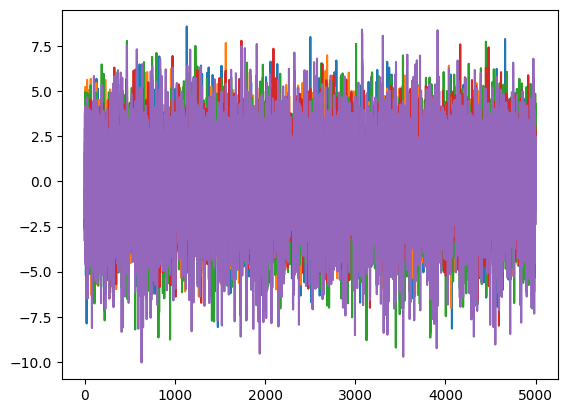

In [3]:
plt.plot(df_a)
plt.show()

In [ ]:
series_names = df_a.columns.tolist() # 获取序列名称
P = len(series_names) # 获取序列数量
X_np = df_a.values  # 获取所有的数据点
T = X_np.shape[0]   # 获取时间点数量 T

5000


In [ ]:
series_to_idx = {name: i for i, name in enumerate(series_names)}

{'0': 0, '1': 1, '2': 2, '3': 3, '4': 4}


In [ ]:
GC_true_np = np.zeros((P, P), dtype=int) # 初始化真实的格兰杰因果矩阵
# 读取真实的格兰杰因果矩阵
for _, row in df_b.iterrows():
    # 修改点：使用 .iloc 按位置访问 Series 中的元素
    cause_name = row.iloc[0]  # 第一列为 "因"
    effect_name = row.iloc[1] # 第二列为 "果"
    # lag_value = row.iloc[2] if df_b.shape[1] > 2 else None # 第三列为 "延迟" (可选)
    str_cause_name = str(cause_name)
    str_effect_name = str(effect_name)

    if str_cause_name in series_to_idx and str_effect_name in series_to_idx:
        idx_cause = series_to_idx[str_cause_name]
        idx_effect = series_to_idx[str_effect_name]
        GC_true_np[idx_effect, idx_cause] = 1

print(f"真实的格兰杰因果矩阵 GC_true_np (形状 {GC_true_np.shape}):\n{GC_true_np}")

真实的格兰杰因果矩阵 GC_true_np (形状 (5, 5)):
[[0 1 0 0 1]
 [0 1 1 0 0]
 [0 0 1 1 0]
 [0 0 0 1 1]
 [0 0 0 0 1]]


In [22]:
# 添加特征维度
X_np = X_np[:, :, np.newaxis] # 形状: [T, P, 1]
print(f"添加特征维度后 X_np 形状: {X_np.shape}")

添加特征维度后 X_np 形状: (5000, 5, 1, 1)


In [23]:
# 分割数据
X_train_val_np, X_test_np = train_test_split(X_np, test_size=0.2, random_state=DATA_SEED, shuffle=False)
X_train_np, X_val_np = train_test_split(X_train_val_np, test_size=0.25, random_state=DATA_SEED, shuffle=False)
print(f"训练集 X_train_np: {X_train_np.shape}")
print(f"验证集 X_val_np: {X_val_np.shape}")
print(f"测试集 X_test_np: {X_test_np.shape}")

训练集 X_train_np: (3000, 5, 1, 1)
验证集 X_val_np: (1000, 5, 1, 1)
测试集 X_test_np: (1000, 5, 1, 1)


In [26]:
# --- 辅助函数：创建序列 (适配 CausalFormer 输入输出) ---
def create_sequences(data, input_seq_len, output_seq_len):
    xs, ys = [], []
    total_len = len(data)
    if total_len < input_seq_len + output_seq_len: # 检查数据长度是否足够
        print(f"警告: 数据总长度 ({total_len}) 不足以创建至少一个长度为 input_seq_len ({input_seq_len}) + output_seq_len ({output_seq_len}) 的序列。")
        return np.array(xs), np.array(ys) # 返回空数组
    for i in range(total_len - input_seq_len - output_seq_len + 1):
        x = data[i:(i + input_seq_len)]
        y = data[(i + input_seq_len):(i + input_seq_len + output_seq_len)]
        xs.append(x)
        ys.append(y)
    if not xs: # 如果循环后列表仍为空
        return np.array(xs), np.array(ys) # 返回空数组
    return np.array(xs), np.array(ys)

In [ ]:
# --- 2. 定义 Optuna 目标函数 (使用 PGD) ---
def objective(trial):
    global X_train_np, X_val_np, GC_true_np, P, FEATURE_DIM, OUTPUT_DIM

    input_window = trial.suggest_categorical('input_window', [10, 20, 30])
    output_window = 1
    d_model = trial.suggest_categorical('d_model', [32, 64, 128])
    n_head = trial.suggest_categorical('n_head', [2, 4, 8])
    n_layers = trial.suggest_int('n_layers', 1, 3)
    ffn_hidden = trial.suggest_categorical('ffn_hidden', [64, 128, 256])
    dropout = trial.suggest_float('dropout', 0.0, 0.3)
    tau = trial.suggest_float('tau', 0.5, 10.0, log=True)
    tcn_layers = trial.suggest_int('tcn_layers', 2, 5)
    tcn_channels = trial.suggest_categorical('tcn_channels', [16, 32, 48])
    tcn_kernel_size = trial.suggest_categorical('tcn_kernel_size', [2, 3, 4])
    tcn_dropout = trial.suggest_float('tcn_dropout', 0.0, 0.3)
    tcn_channel_list = [tcn_channels] * tcn_layers
    lr = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    lambda_reg = trial.suggest_float('lambda_reg', 1e-5, 1e-1, log=True)
    penalty_type = trial.suggest_categorical('penalty_type', ['GL', 'GSGL'])
    alpha_gsgl = 0.5
    if penalty_type == 'GSGL':
        alpha_gsgl = trial.suggest_float('alpha_gsgl', 0.1, 0.9)

    print(f"\n--- Trial {trial.number} ---")
    print(f"  CausalFormer 参数: input_window={input_window}, d_model={d_model}, n_head={n_head}, n_layers={n_layers}, ffn_hidden={ffn_hidden}, dropout={dropout:.3f}, tau={tau:.3f}")
    print(f"  GrangerTCN 参数: layers={tcn_layers}, channels={tcn_channels}, kernel={tcn_kernel_size}, dropout={tcn_dropout:.3f}")
    print(f"  优化参数: lr={lr:.6f}, lambda_reg={lambda_reg:.6f}, penalty={penalty_type}"
          f"{f', alpha={alpha_gsgl:.2f}' if penalty_type == 'GSGL' else ''}")

    X_train_seq, y_train_seq = create_sequences(X_train_np, input_window, output_window)
    X_val_seq, y_val_seq = create_sequences(X_val_np, input_window, output_window)

    if X_train_seq.size == 0 or X_val_seq.size == 0:
        print(f"警告 (Trial {trial.number}): 由于输入窗口 ({input_window}) 或数据长度不足，未能创建训练或验证序列。跳过此 Trial。")
        return -1.0 # 返回一个差的值，Optuna 会尝试其他参数

    X_train_tensor = torch.tensor(X_train_seq, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train_seq, dtype=torch.float32)
    X_val_tensor = torch.tensor(X_val_seq, dtype=torch.float32)
    y_val_tensor = torch.tensor(y_val_seq, dtype=torch.float32)

    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
    
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

    config = {
        'data_loader': {
            'args': {
                'time_step': input_window, 'output_window': output_window,
                'series_num': P, 'feature_dim': FEATURE_DIM, 'output_dim': OUTPUT_DIM
            }
        },
        'device': DEVICE.type 
    }

    model = PredictModel(config=config, d_model=d_model, n_head=n_head, n_layers=n_layers,
                         tcn_channels=tcn_channel_list, tcn_kernel_size=tcn_kernel_size,
                         tcn_dropout=tcn_dropout, ffn_hidden=ffn_hidden,
                         drop_prob=dropout, tau=tau).to(DEVICE)
    criterion = nn.MSELoss()
    try:
        granger_weights_param = model.encoder.layers[0].attention.tcn_processor.network_layers[0].conv1.weight
    except AttributeError as e:
        print(f"警告 (Trial {trial.number}): 无法访问 granger_weights_param: {e}. 可能模型层数 ({n_layers} 或 {tcn_layers}) 不足。正则化将不生效。")
        granger_weights_param = None


    for epoch in range(EPOCHS):
        model.train()
        epoch_loss = 0.0
        epoch_penalty = 0.0
        num_batches = 0
        if not train_loader: # 如果 train_loader 为空 (由于 drop_last 和小数据集)
             print(f"警告 (Trial {trial.number}, Epoch {epoch+1}): train_loader 为空，跳过训练步骤。")
             # 这种情况下，可能需要提前结束 trial 或返回一个表示失败的值
             # 为了简单起见，我们继续，但模型不会被训练
        else:
            for batch_x, batch_y in train_loader:
                batch_x, batch_y = batch_x.to(DEVICE), batch_y.to(DEVICE)
                model.zero_grad()
                predictions = model(batch_x)
                main_loss = criterion(predictions, batch_y)
                main_loss.backward()
                epoch_loss += main_loss.item()
                num_batches += 1
                with torch.no_grad():
                    current_penalty = torch.tensor(0.0, device=DEVICE)
                    if granger_weights_param is not None and hasattr(granger_weights_param, 'data'):
                        current_weights = granger_weights_param.data
                        if penalty_type == 'GL':
                            current_penalty = calculate_group_lasso_penalty(current_weights, lambda_reg)
                        elif penalty_type == 'GSGL':
                            current_penalty = calculate_group_sparse_group_lasso_penalty(current_weights, lambda_reg, alpha_gsgl)
                    epoch_penalty += current_penalty.item()
                    for name, param in model.named_parameters():
                        if param.grad is None: continue
                        is_regularized_weight = (granger_weights_param is not None and param is granger_weights_param)
                        if is_regularized_weight:
                            w_tilde = param.data - lr * param.grad
                            lambda_gamma = lr * lambda_reg
                            w_new = torch.zeros_like(w_tilde)
                            if penalty_type == 'GL':
                                for j in range(w_tilde.shape[1]):
                                    w_new[:, j, :] = prox_group_lasso(w_tilde[:, j, :], lambda_gamma)
                            elif penalty_type == 'GSGL':
                                for j in range(w_tilde.shape[1]):
                                    w_new[:, j, :] = prox_group_sparse_group_lasso(w_tilde[:, j, :], lambda_gamma, alpha_gsgl)
                            param.copy_(w_new)
                        else:
                            param.copy_(param.data - lr * param.grad)
        
        avg_epoch_loss = epoch_loss / num_batches if num_batches > 0 else 0
        avg_epoch_penalty = epoch_penalty / num_batches if num_batches > 0 else 0
        print(f"  Epoch {epoch+1}/{EPOCHS}, Avg Train Loss: {avg_epoch_loss:.6f}, Avg Penalty: {avg_epoch_penalty:.6f}")

        model.eval()
        val_mse = 0.0
        learned_norms = np.zeros(P) if P > 0 else np.array([]) # Handle P=0 case
        current_val_auroc = 0.0
        avg_val_mse = float('inf')

        if not val_loader.dataset:
            print(f"警告 (Trial {trial.number}, Epoch {epoch+1}): 验证集为空，跳过验证。")
            # Optuna 期望一个返回值，即使是剪枝的情况
        else:
            with torch.no_grad():
                for batch_x, batch_y in val_loader:
                    batch_x, batch_y = batch_x.to(DEVICE), batch_y.to(DEVICE)
                    predictions = model(batch_x)
                    loss = criterion(predictions, batch_y)
                    val_mse += loss.item() * batch_x.size(0)
                if len(val_loader.dataset) > 0: avg_val_mse = val_mse / len(val_loader.dataset)

                if P > 0: # 仅当P>0时才尝试获取权重和计算AUROC
                    final_weights = model.get_granger_weights(layer_index=0)
                    if final_weights is not None:
                        for j in range(P):
                            norm_val = torch.linalg.norm(final_weights[:, j, :].float(), ord='fro').cpu().item()
                            learned_norms[j] = norm_val if np.isfinite(norm_val) else 0.0
                    else:
                        learned_norms = np.zeros(P)

                    true_causes = np.array([np.any(GC_true_np[np.arange(P) != k, k] == 1) for k in range(P)], dtype=int)
                    scores = learned_norms
                    if len(np.unique(true_causes)) > 1 and not np.all(np.isnan(scores)) and len(scores) == len(true_causes) and np.sum(~np.isnan(scores)) > 0:
                        valid_indices = ~np.isnan(scores)
                        if len(np.unique(true_causes[valid_indices])) > 1:
                            try:
                                current_val_auroc = roc_auc_score(true_causes[valid_indices], scores[valid_indices])
                            except ValueError as e:
                                print(f"警告 (Trial {trial.number}): 计算 AUROC 时出错: {e}. AUROC 设为 0.0")
                                current_val_auroc = 0.0
                        else:
                            print(f"警告 (Trial {trial.number}): AUROC 条件不足 (过滤后只有一个类别)。AUROC 设为 0.0")
                            current_val_auroc = 0.0
                    else:
                        print(f"警告 (Trial {trial.number}): 无法计算 AUROC (true_causes中只有一个类别或scores无效)。AUROC 设为 0.0")
                        current_val_auroc = 0.0
                else: # P == 0
                    print(f"警告 (Trial {trial.number}): P=0, 无法计算 learned_norms 和 AUROC。")
                    current_val_auroc = 0.0 # 或者 -1.0

        final_val_auroc = current_val_auroc
        trial.report(final_val_auroc, epoch)
        if trial.should_prune():
            print(f"Trial {trial.number} 在第 {epoch+1} 轮被剪枝。")
            return -1.0

    print(f"Trial {trial.number} 完成。最终验证集 AUROC: {final_val_auroc:.4f}, 最终验证集 MSE: {avg_val_mse:.6f}")
    return final_val_auroc if np.isfinite(final_val_auroc) else -1.0
